In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rv_continuous
from scipy import integrate

# 1. Определение собственного распределения
class CustomDistribution(rv_continuous):
    def __init__(self, a=0.0, b=np.pi/2):
        super().__init__(a=a, b=b, name='cos2_dist')
    
    def _pdf(self, x):
        result = np.zeros_like(x, dtype=float)
        mask = (x >= self.a) & (x <= self.b)
        result[mask] = (4 / np.pi) * np.cos(x[mask])**2
        return result
    
    def _cdf(self, x):
        result = np.zeros_like(x, dtype=float)
        result[x < self.a] = 0.0
        mask = (x >= self.a) & (x <= self.b)
        xm = x[mask]
        result[mask] = (2 / np.pi) * (xm + 0.5 * np.sin(2 * xm))
        result[x > self.b] = 1.0
        return result
    

# Создание экземпляра
a, b = 0.0, np.pi / 2
custom_dist = CustomDistribution(a, b)

print("АНАЛИЗ СОБСТВЕННОГО РАСПРЕДЕЛЕНИЯ")
print("Плотность: f(x) = (4/π)·cos²(x) на [0, π/2]")

# Генерация выборки
np.random.seed(42)
sample = custom_dist.rvs(size=10000)
print(f"\nРазмер выборки: {len(sample)}")
print(f"Первые 10 значений: {sample[:10]}")

АНАЛИЗ СОБСТВЕННОГО РАСПРЕДЕЛЕНИЯ
Плотность: f(x) = (4/π)·cos²(x) на [0, π/2]

Размер выборки: 10000
Первые 10 значений: [0.30329317 1.07484351 0.664386   0.51283806 0.12315754 0.12313831
 0.04565046 0.86727519 0.51538281 0.63475887]


In [11]:
integral, error = integrate.quad(custom_dist.pdf, a, b)
print(f"∫f(x)dx на [{a:.4f}, {b:.4f}] = {integral:.10f}")
print(f"Ошибка интегрирования: {error:.2e}")

if abs(integral - 1.0) < 1e-8:
    print("Условие нормировки выполнено: ∫f(x)dx = 1")
else:
    print("Условие нормировки НЕ выполнено!")

print("\nПроверка CDF:")
print(f"F({a:.4f}) = {custom_dist.cdf(a):.10f} (должно быть 0)")
print(f"F({b:.4f}) = {custom_dist.cdf(b):.10f} (должно быть 1)")


∫f(x)dx на [0.0000, 1.5708] = 1.0000000000
Ошибка интегрирования: 1.11e-14
Условие нормировки выполнено: ∫f(x)dx = 1

Проверка CDF:
F(0.0000) = 0.0000000000 (должно быть 0)
F(1.5708) = 1.0000000000 (должно быть 1)


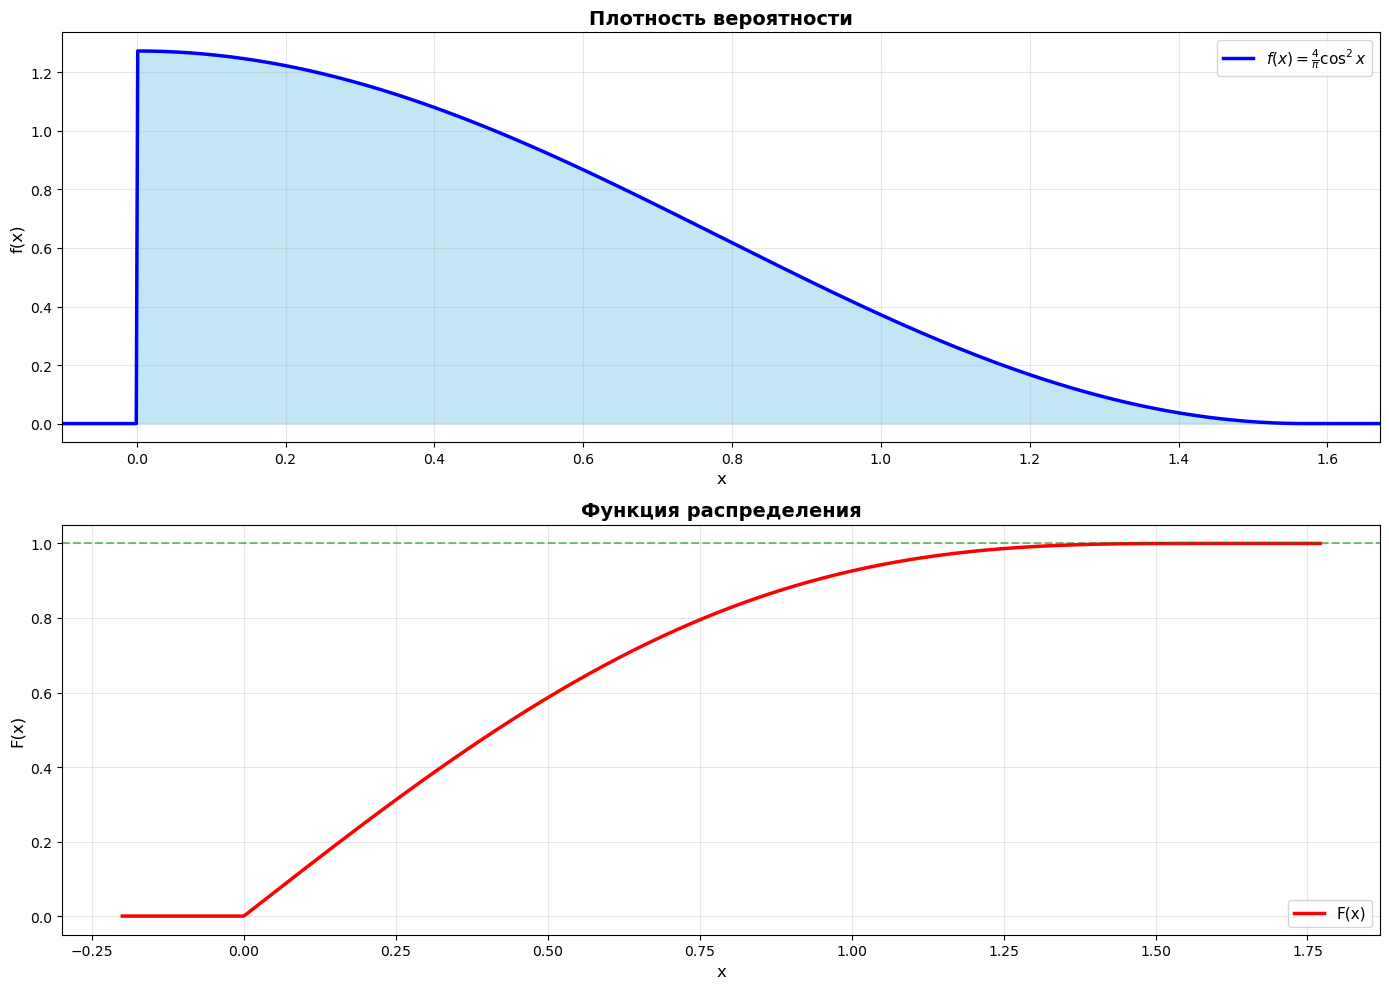

In [3]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(14, 10))
x_plot = np.linspace(-0.2, np.pi/2 + 0.2, 1000)

ax1.plot(x_plot, custom_dist.pdf(x_plot), 'b-', lw=2.5, label=r'$f(x) = \frac{4}{\pi} \cos^2 x$')
ax1.fill_between(x_plot, 0, custom_dist.pdf(x_plot), color='skyblue', alpha=0.5)
ax1.set_xlim(-0.1, np.pi/2 + 0.1)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('Плотность вероятности', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(x_plot, custom_dist.cdf(x_plot), 'r-', lw=2.5, label='F(x)')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x)', fontsize=12)
ax2.set_title('Функция распределения', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1, color='g', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [12]:
intervals = [(0.0, np.pi/4), (np.pi/6, np.pi/3), (0.5, 1.0)]
for x1, x2 in intervals:
    prob = custom_dist.cdf(x2) - custom_dist.cdf(x1)
    print(f"P({x1:.4f} ≤ X ≤ {x2:.4f}) = {prob:.6f}")


P(0.0000 ≤ X ≤ 0.7854) = 0.818310
P(0.5236 ≤ X ≤ 1.0472) = 0.333333
P(0.5000 ≤ X ≤ 1.0000) = 0.339900


In [13]:
mean = custom_dist.mean()
var = custom_dist.var()
std = custom_dist.std()
print(f"Математическое ожидание E[X]: {mean:.6f}")
print(f"Дисперсия D[X]: {var:.6f}")
print(f"СКО σ: {std:.6f}")


Математическое ожидание E[X]: 0.467088
Дисперсия D[X]: 0.104296
СКО σ: 0.322948


In [14]:
for q in [0.25, 0.5, 0.75]:
    print(f"{q}-квантиль: {custom_dist.ppf(q):.6f}")

0.25-квантиль: 0.198954
0.5-квантиль: 0.415856
0.75-квантиль: 0.687626


In [15]:
_, _, skew, kurt = custom_dist.stats(moments='mvsk')
print(f"Коэффициент асимметрии: {skew:.6f}")
print(f"Эксцесс: {kurt:.6f}")

Коэффициент асимметрии: 0.601586
Эксцесс: -0.404750
